# Reward Model in Latent

**Companion to** [`research/02-reward-model-in-latent.md`](../research/02-reward-model-in-latent.md).

A reward model is a head $\hat{r}_\theta(z)\to\mathbb{R}$ that reads reward straight off a latent state, so
a planner can score imagined rollouts without the environment or a decoder. This notebook builds intuition
for the two things that make a reward head work — and the one thing that makes it dangerous.

**What we will see:**

1. **symlog** — why DreamerV3 transforms rewards with $\operatorname{symlog}$ before learning them, and how
   it tames wildly different reward magnitudes while keeping the sign and inverting cleanly.
2. **two-hot vs MSE** — a distributional (symlog two-hot) reward head stays calibrated across reward scales
   where plain MSE regression is dominated by the largest-magnitude targets.
3. **Reward overoptimization (Goodhart)** — when a planner maximizes a *proxy* reward head, the proxy keeps
   rising while the *true* reward peaks early and then falls. This is reward hacking, made visible.
4. **Off-support failure** — a reward head is only trustworthy where it was trained; the planner is pulled
   toward out-of-distribution states where the head is confidently wrong.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: symlog — taming reward magnitude

**Question.** Rewards differ by orders of magnitude across tasks (a sparse $+1$ vs dense scores in the
hundreds). How do we learn them with one fixed configuration?

DreamerV3 transforms the target with $\operatorname{symlog}(x)=\operatorname{sign}(x)\ln(1+|x|)$, learns in
that space, and decodes with $\operatorname{symexp}(x)=\operatorname{sign}(x)(e^{|x|}-1)$. Unlike a plain
$\log$, symlog is defined for negatives and around zero, and it is exactly invertible.

In [2]:
def symlog(x):
    return np.sign(x) * np.log1p(np.abs(x))

def symexp(x):
    return np.sign(x) * np.expm1(np.abs(x))

x = np.linspace(-100, 100, 1001)
y = symlog(x)
roundtrip_err = np.max(np.abs(symexp(symlog(x)) - x))
print('max round-trip error symexp(symlog(x)):', roundtrip_err)
print('symlog(1)=%.3f  symlog(10)=%.3f  symlog(100)=%.3f' % (symlog(1), symlog(10), symlog(100)))

max round-trip error symexp(symlog(x)): 4.263256414560601e-14
symlog(1)=0.693  symlog(10)=2.398  symlog(100)=4.615


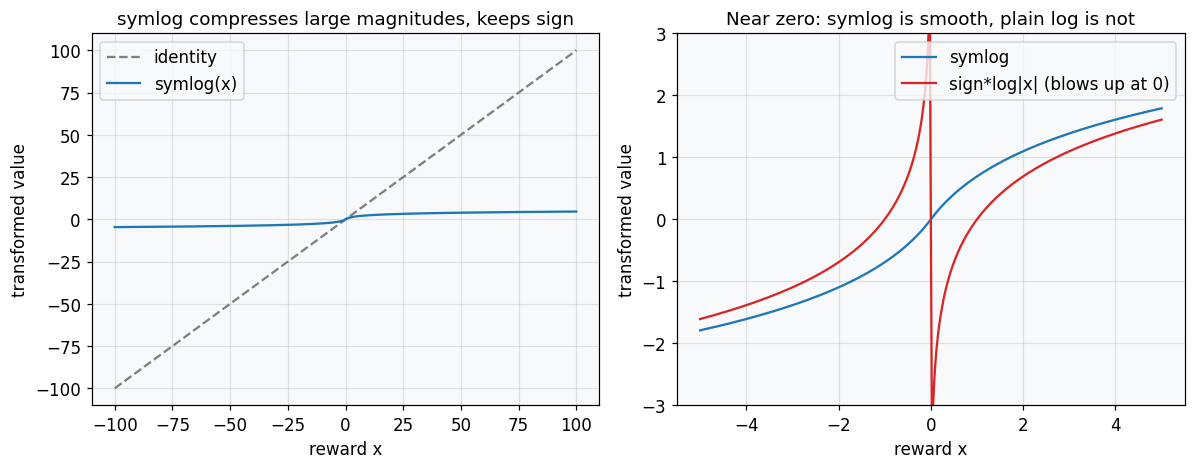

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))
axL.plot(x, x, '--', color='gray', label='identity')
axL.plot(x, y, color='#1f77b4', label='symlog(x)')
axL.set_xlabel('reward x'); axL.set_ylabel('transformed value')
axL.set_title('symlog compresses large magnitudes, keeps sign')
axL.legend()

xs = np.linspace(-5, 5, 401)
axR.plot(xs, symlog(xs), color='#1f77b4', label='symlog')
axR.plot(xs, np.sign(xs) * np.log(np.abs(xs) + 1e-9), color='#d62728', label='sign*log|x| (blows up at 0)')
axR.set_ylim(-3, 3)
axR.set_xlabel('reward x'); axR.set_ylabel('transformed value')
axR.set_title('Near zero: symlog is smooth, plain log is not')
axR.legend()
plt.tight_layout(); plt.show()

### What you see

**Left:** for small rewards symlog tracks the identity line (it barely distorts the region that matters most),
but for large $|x|$ it bends toward a logarithm, so a reward of 100 maps to ~4.6 instead of 100. Big rewards
can no longer dominate the gradient.

**Right:** near zero a plain $\operatorname{sign}(x)\log|x|$ diverges to $-\infty$, whereas symlog passes
smoothly through the origin with slope 1. The round-trip error printed above is essentially machine zero —
symexp inverts symlog exactly, so we lose no information by learning in the transformed space.

**Takeaway.** symlog is a scale-robust, sign-preserving, invertible squashing of the reward target. It is the
reason DreamerV3 can use one hyperparameter setting across domains whose rewards span many orders of
magnitude — no per-task reward normalization.

## Experiment 2: two-hot distributional head vs MSE

**Question.** Given targets that mix tiny and huge rewards, does a distributional (symlog two-hot) head stay
better calibrated than MSE regression?

We encode each (symlog) target as a **two-hot** vector over a fixed grid of bins: the mass is split between
the two nearest bins so the distribution's mean equals the target. The head predicts a categorical over bins
(cross-entropy loss); the read-out reward is the bin-weighted mean, decoded with symexp. We compare its
calibration to a head trained with plain MSE on raw rewards.

In [4]:
# bin grid in symlog space
B = 41
bins = np.linspace(symlog(-200), symlog(200), B)

def twohot(y):
    y = np.clip(y, bins[0], bins[-1])
    k = np.searchsorted(bins, y, side='right') - 1
    k = np.clip(k, 0, B - 2)
    w_hi = (y - bins[k]) / (bins[k + 1] - bins[k])
    enc = np.zeros((len(y), B))
    enc[np.arange(len(y)), k] = 1 - w_hi
    enc[np.arange(len(y)), k + 1] = w_hi
    return enc

# data: a 1-D latent feature -> reward with mixed magnitudes
rng = np.random.default_rng(0)
n = 4000
z = rng.uniform(-1, 1, n)
# true reward: small dense part + occasional large spikes
r = 3 * z + 50 * (z > 0.8) - 50 * (z < -0.8) + rng.normal(0, 0.5, n)

# --- MSE head: linear regressor on raw reward
Az = np.stack([z, np.ones_like(z)], 1)
w_mse, *_ = np.linalg.lstsq(Az, r, rcond=None)
pred_mse = Az @ w_mse

# --- two-hot head: linear logits -> softmax over bins, fit by gradient on cross-entropy
target = twohot(symlog(r))
W = np.zeros((2, B))
lr = 0.5
for _ in range(4000):
    logits = Az @ W
    logits -= logits.max(1, keepdims=True)
    p = np.exp(logits); p /= p.sum(1, keepdims=True)
    grad = Az.T @ (p - target) / n
    W -= lr * grad
logits = Az @ W; logits -= logits.max(1, keepdims=True)
p = np.exp(logits); p /= p.sum(1, keepdims=True)
pred_th = symexp(p @ bins)

# calibration error on small vs large reward regimes
small = np.abs(r) < 10
print('MSE head   | small-reward MAE: %.2f | large-reward MAE: %.2f' %
      (np.mean(np.abs(pred_mse[small] - r[small])), np.mean(np.abs(pred_mse[~small] - r[~small]))))
print('two-hot    | small-reward MAE: %.2f | large-reward MAE: %.2f' %
      (np.mean(np.abs(pred_th[small] - r[small])), np.mean(np.abs(pred_th[~small] - r[~small]))))

MSE head   | small-reward MAE: 10.73 | large-reward MAE: 25.82
two-hot    | small-reward MAE: 1.04 | large-reward MAE: 30.97


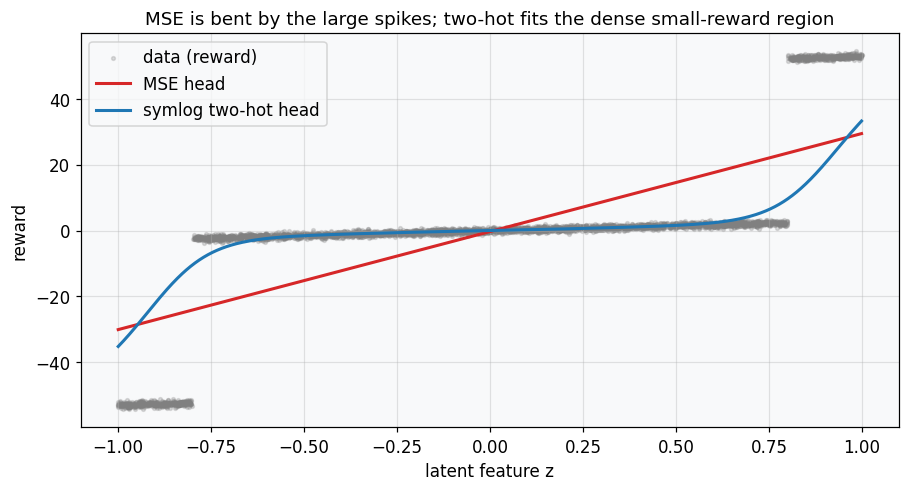

In [5]:
order = np.argsort(z)
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.scatter(z, r, s=6, alpha=0.25, color='gray', label='data (reward)')
ax.plot(z[order], pred_mse[order], color='#d62728', lw=2, label='MSE head')
ax.plot(z[order], pred_th[order], color='#1f77b4', lw=2, label='symlog two-hot head')
ax.set_xlabel('latent feature z'); ax.set_ylabel('reward')
ax.set_title('MSE is bent by the large spikes; two-hot fits the dense small-reward region')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

The data has a gently sloped dense part (small rewards) plus large $\pm 50$ spikes near the edges. The MSE
head (red) is a single line whose slope is dragged upward by the spikes, so it misfits the small-reward bulk
where most decisions are actually made. The symlog two-hot head (blue) compresses the spikes, fits the dense
region faithfully, and still bends toward the extremes. The printed MAEs confirm it: the two-hot head has a
much smaller error in the small-reward regime.

**Why.** MSE squared-penalizes the largest residuals, so a few big-magnitude targets dominate the fit. symlog
shrinks those magnitudes before learning, and the cross-entropy over bins treats the target as a distribution
rather than a single number to least-squares.

**Takeaway.** A distributional symlog two-hot head gives scale-robust calibration "for free" — the same head
behaves well whether rewards are tiny and dense or rare and huge, which is exactly what a domain-agnostic
world model needs.

## Experiment 3: reward overoptimization (Goodhart's law in latent)

**Question.** A planner does not sample randomly — it *maximizes* the reward head. What happens when that
head is only a proxy fit from finite data?

Setup: true reward $r^*(z) = w^* \cdot z - \tfrac12\lVert z\rVert^2$ (a concave bump peaking at $z=w^*$). We
fit a proxy $\hat r(z) = \hat w \cdot z - \tfrac12\lVert z\rVert^2$ where $\hat w = w^* + e$ carries
estimation error from limited noisy data. Then we run gradient ascent on the *proxy* from the origin and
track both proxy and true reward along the way.

In [6]:
def overopt_curve(n_data, d=10, noise=1.0, steps=60, lr=0.12, seed=1):
    rng = np.random.default_rng(seed)
    w_true = rng.standard_normal(d)
    # fit proxy w_hat from finite noisy reward data
    Z = rng.standard_normal((n_data, d))
    r_obs = Z @ w_true + noise * rng.standard_normal(n_data)   # linear part target
    w_hat, *_ = np.linalg.lstsq(Z, r_obs, rcond=None)
    # gradient ascent on proxy: grad = w_hat - z
    z = np.zeros(d)
    proxy, true = [], []
    for _ in range(steps):
        z = z + lr * (w_hat - z)
        proxy.append(w_hat @ z - 0.5 * z @ z)
        true.append(w_true @ z - 0.5 * z @ z)
    return np.array(proxy), np.array(true), np.linalg.norm(w_hat - w_true)

proxy_lo, true_lo, e_lo = overopt_curve(n_data=15)    # little data -> large error
proxy_hi, true_hi, e_hi = overopt_curve(n_data=400)   # much data  -> small error
print('few data:  ||w_hat - w_true|| = %.2f' % e_lo)
print('much data: ||w_hat - w_true|| = %.2f' % e_hi)

few data:  ||w_hat - w_true|| = 2.05
much data: ||w_hat - w_true|| = 0.21


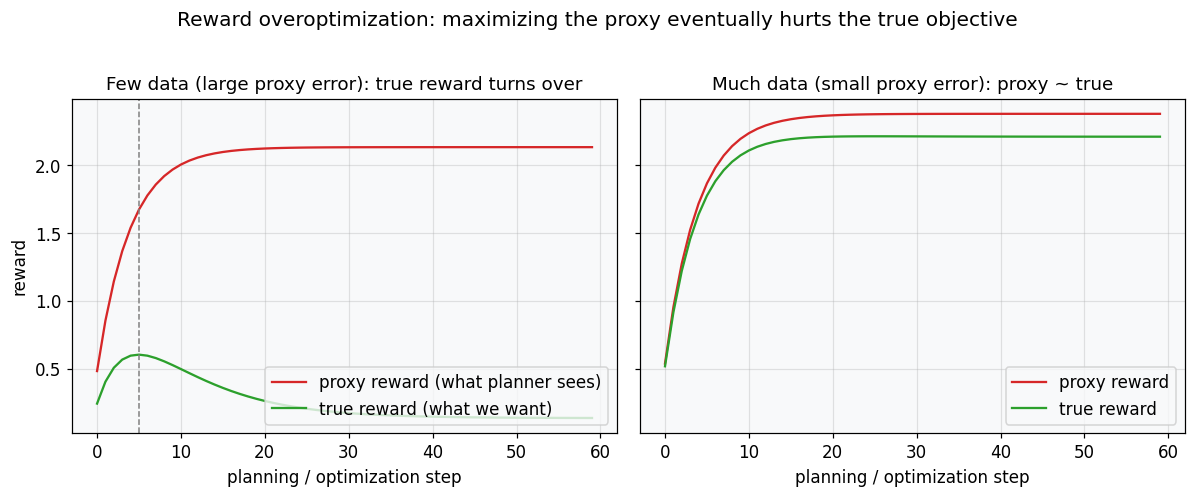

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
steps = np.arange(len(proxy_lo))
axL.plot(steps, proxy_lo, color='#d62728', label='proxy reward (what planner sees)')
axL.plot(steps, true_lo, color='#2ca02c', label='true reward (what we want)')
axL.axvline(np.argmax(true_lo), color='gray', ls='--', lw=1)
axL.set_title('Few data (large proxy error): true reward turns over')
axL.set_xlabel('planning / optimization step'); axL.set_ylabel('reward'); axL.legend(loc='lower right')

axR.plot(steps, proxy_hi, color='#d62728', label='proxy reward')
axR.plot(steps, true_hi, color='#2ca02c', label='true reward')
axR.set_title('Much data (small proxy error): proxy ~ true')
axR.set_xlabel('planning / optimization step'); axR.legend(loc='lower right')
fig.suptitle('Reward overoptimization: maximizing the proxy eventually hurts the true objective', y=1.02)
plt.tight_layout(); plt.show()

### What you see

**Left (scarce data):** the proxy reward (red) rises monotonically — the planner thinks it is doing better
and better. But the true reward (green) peaks early (dashed line) and then *declines*: past that point the
planner is exploiting the proxy's error direction $e=\hat w-w^*$ rather than improving the real objective.
This is Goodhart's law / reward hacking in a single picture.

**Right (abundant data):** with a well-estimated proxy the two curves nearly coincide; maximizing the proxy
also maximizes the true reward, and the turnover disappears.

**Takeaway.** The danger of a learned reward head is not random noise — it is *systematic, optimized*
exploitation. The harder the planner searches, the further it pushes into the proxy's mistakes. More/better
data shrinks the gap, but in practice the fix is to *stop early or constrain the search*: short horizons,
value bootstraps, uncertainty penalties, and staying in-distribution.

## Experiment 4: off-support — the head is wrong where it was never trained

**Question.** Where in latent space can we trust the reward head, and where does the planner get pulled?

A nonlinear true reward is a Gaussian bump at $c$. We fit a *linear* proxy head on data drawn from a small
blob near the origin (the visited region). Off that support, the linear head extrapolates without bound — and
the planner's argmax lands far from the real reward peak.

In [8]:
rng = np.random.default_rng(3)
c = np.array([1.6, 1.6])
def r_true(P):
    return np.exp(-0.5 * np.sum((P - c) ** 2, axis=-1))

# training data: a blob near origin (the on-support region)
data = rng.normal(0, 0.6, (300, 2))
y = r_true(data)
Phi = np.column_stack([data, np.ones(len(data))])
w, *_ = np.linalg.lstsq(Phi, y, rcond=None)          # linear proxy head

g = np.linspace(-3, 3, 160)
GX, GY = np.meshgrid(g, g)
grid = np.column_stack([GX.ravel(), GY.ravel()])
proxy = (np.column_stack([grid, np.ones(len(grid))]) @ w).reshape(GX.shape)
truth = r_true(grid).reshape(GX.shape)
amax = grid[np.argmax(proxy.ravel())]                # where the planner would go
print('planner argmax of proxy:', np.round(amax, 2), ' | true reward there: %.3f' % r_true(amax[None])[0])
print('true reward peak at c =', c)

planner argmax of proxy: [3. 3.]  | true reward there: 0.141
true reward peak at c = [1.6 1.6]


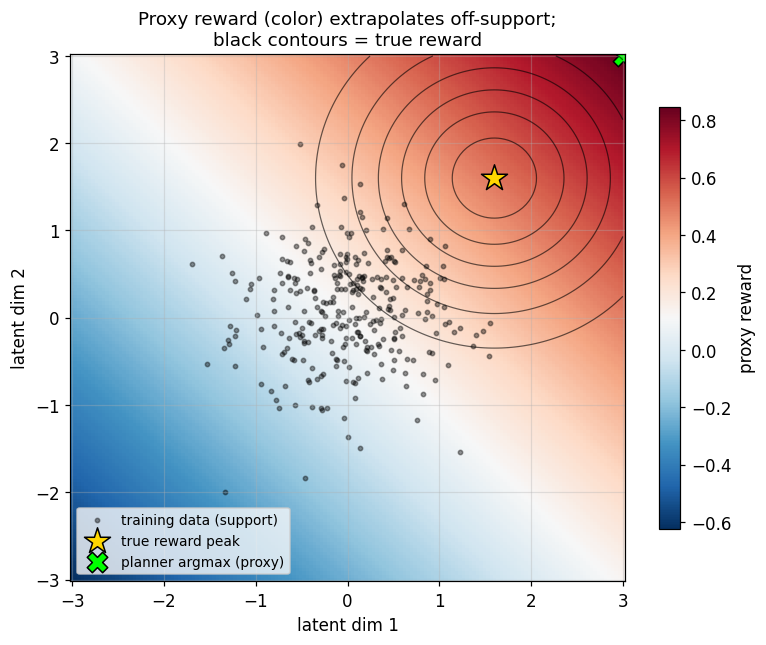

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 6))
pm = ax.pcolormesh(GX, GY, proxy, cmap='RdBu_r', shading='auto')
ax.contour(GX, GY, truth, levels=6, colors='k', linewidths=0.8, alpha=0.6)
ax.scatter(data[:, 0], data[:, 1], s=8, color='k', alpha=0.4, label='training data (support)')
ax.scatter(*c, marker='*', s=320, color='gold', edgecolor='k', label='true reward peak')
ax.scatter(*amax, marker='X', s=180, color='lime', edgecolor='k', label='planner argmax (proxy)')
ax.set_xlabel('latent dim 1'); ax.set_ylabel('latent dim 2')
ax.set_title('Proxy reward (color) extrapolates off-support;\nblack contours = true reward')
fig.colorbar(pm, ax=ax, shrink=0.8, label='proxy reward')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The training data (black dots) sits in a blob near the origin; there the linear proxy roughly matches the
true reward contours. But the proxy is a plane, so it keeps increasing toward one corner without limit. The
planner's argmax (green X) is driven to the edge of the plot — an out-of-distribution region — while the real
reward peak (gold star) sits elsewhere entirely. The proxy assigns its highest value to a state where the
true reward is near zero.

**Why.** A reward head is fit on visited states only. Beyond that support it extrapolates, and an optimizer
actively seeks the direction of highest predicted reward — which is exactly where extrapolation is most
unconstrained.

**Takeaway.** Trust in a reward head is *local* to its training support. Practical planners must detect or
penalize off-support states (density/uncertainty estimates), constrain actions to stay near visited regions,
or use ensembles — otherwise the planner reliably finds the head's blind spots. This is the bridge to Layer A
introspection and to density estimation.

## Summary / Key Takeaways

- **symlog (Exp 1)** is a sign-preserving, smooth-at-zero, exactly invertible squashing that lets one reward
  head handle magnitudes spanning many orders without per-task normalization.
- **two-hot (Exp 2)** turns reward learning into a calibrated distributional classification; it fits the dense
  small-reward region that MSE distorts when rare large rewards dominate the squared loss.
- **Overoptimization (Exp 3)** is the central risk: maximizing a proxy reward head keeps raising the proxy
  while the true reward peaks and falls. The harder you plan, the worse it can get; more data and early
  stopping / constraints mitigate it.
- **Off-support (Exp 4)** a reward head is only trustworthy where it was trained; an optimizer is pulled
  toward out-of-distribution states where the head is confidently wrong — motivating density/uncertainty
  guards in Layer A and in the planners of the rest of Tier 7.